# ChIP-seq analysis: H3K27ac regulatory landscape in primary human liver tissue

A downstream ChIP-seq analysis on public **ENCODE** data for **primary human liver tissue** (donor
liver, not a cell line). H3K27ac marks active promoters and enhancers, so starting from called peaks
and a signal track this notebook maps the active regulatory landscape of the liver — peak statistics,
where marks sit relative to genes, the TSS-enrichment heatmap, and the genes with the strongest
promoter activity.

Files are pulled straight from the ENCODE portal API (no login), so it reproduces on Google Colab.
Runtime ~5-10 min. All figures are written to `results/`.

**Data:** ENCODE Project — H3K27ac Histone ChIP-seq in human liver tissue (GRCh38). ENCODE Project
Consortium, *Nature* 2012 / *Nature* 2020.

## 1. Setup

In [1]:
!pip install -q deeptools pybedtools pandas matplotlib seaborn requests
!apt-get -qq install -y bedtools >/dev/null
import os, gzip, io, requests, subprocess
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pybedtools
os.makedirs('results', exist_ok=True)
print("ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 56.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.8/208.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.0/187.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 63.8 MB/s eta 0:00:00
ready


## 2. Fetch ENCODE human liver H3K27ac files (peaks + signal)

Query the ENCODE API for a released H3K27ac Histone ChIP-seq experiment on human liver tissue, then
grab the called peaks (bed narrowPeak) and a fold-change-over-control signal track (bigWig) on GRCh38.
(Histone marks use "replicated peaks"; the picker falls back across ENCODE's peak types.)

In [2]:
API = "https://www.encodeproject.org"
hdr = {"accept": "application/json"}

# search released H3K27ac histone ChIP-seq on HUMAN liver tissue, GRCh38
search = requests.get(f"{API}/search/", headers=hdr, params={
    "type": "Experiment", "assay_title": "Histone ChIP-seq", "target.label": "H3K27ac",
    "biosample_ontology.term_name": "liver",
    "replicates.library.biosample.donor.organism.scientific_name": "Homo sapiens",
    "assembly": "GRCh38", "status": "released", "limit": "25", "format": "json"}).json()["@graph"]

def pick(files, fmt, out_types):
    for out_type in out_types:
        for f in files:
            if f.get("file_format") == fmt and f.get("output_type") == out_type \
               and f.get("assembly") == "GRCh38" and f.get("status") == "released":
                return API + f["href"]
    return None

# walk candidates until one has BOTH a GRCh38 peak file and a bigWig signal track
peak_url = bw_url = acc = None
for exp in search:
    files = requests.get(f"{API}/experiments/{exp['accession']}/", headers=hdr).json()["files"]
    p = pick(files, "bed", ["replicated peaks", "pseudoreplicated peaks", "IDR thresholded peaks", "peaks"])
    b = pick(files, "bigWig", ["fold change over control", "signal p-value"])
    if p and b:
        acc, peak_url, bw_url = exp["accession"], p, b
        print("using experiment:", acc, "-", exp["description"][:80])
        break

assert peak_url and bw_url, "No human-liver GRCh38 H3K27ac experiment with both peaks + signal found"
print("peaks:", peak_url); print("signal:", bw_url)
!wget -q -O peaks.bed.gz "{peak_url}"
!wget -q -O signal.bw "{bw_url}"
!gunzip -f peaks.bed.gz
!ls -lh peaks.bed signal.bw   # sanity check: both files should be non-empty

using experiment: ENCSR458RRZ - 
peaks: https://www.encodeproject.org/files/ENCFF813EXR/@@download/ENCFF813EXR.bed.gz
signal: https://www.encodeproject.org/files/ENCFF888QSH/@@download/ENCFF888QSH.bigWig
-rw-r--r-- 1 root root 4.5M Feb  9  2019 peaks.bed
-rw-r--r-- 1 root root 429M Feb  9  2019 signal.bw


## 3. Peaks: count and width distribution

67,641 peaks | median width 653 bp


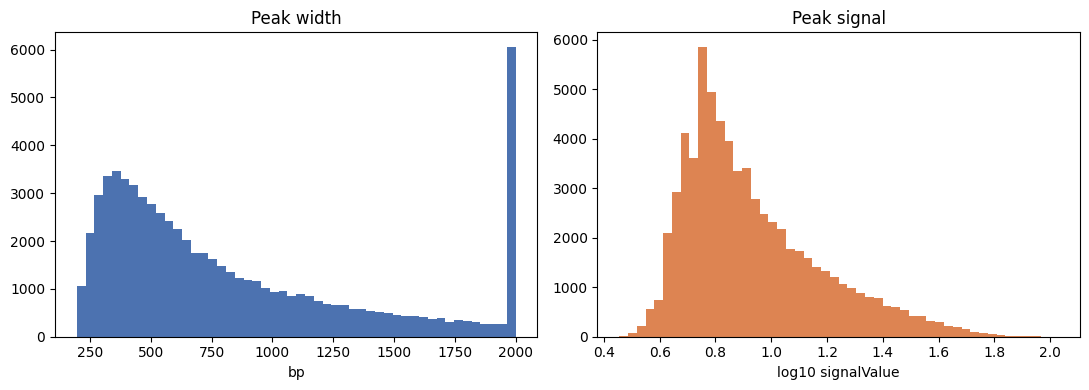

In [3]:
cols = ['chrom','start','end','name','score','strand','signalValue','pValue','qValue','peak']
peaks = pd.read_csv('peaks.bed', sep='\t', header=None, names=cols)
peaks = peaks[peaks['chrom'].str.match(r'chr[0-9XY]+$')].copy()
peaks['width'] = peaks['end'] - peaks['start']
print(f"{len(peaks):,} peaks | median width {int(peaks['width'].median())} bp")

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].hist(peaks['width'].clip(upper=2000), bins=50, color='#4C72B0'); ax[0].set(title='Peak width', xlabel='bp')
ax[1].hist(np.log10(peaks['signalValue']+1), bins=50, color='#DD8452'); ax[1].set(title='Peak signal', xlabel='log10 signalValue')
plt.tight_layout(); plt.savefig('results/peak_stats.png', dpi=120); plt.show()

## 4. Build TSS annotation from GENCODE

In [4]:
# GENCODE basic gene annotation -> one TSS per gene
!wget -q -O gencode.gtf.gz https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.basic.annotation.gtf.gz
rows = []
with gzip.open('gencode.gtf.gz','rt') as fh:
    for line in fh:
        if line.startswith('#'): continue
        f = line.split('\t')
        if f[2] != 'gene': continue
        attr = f[8]
        gname = attr.split('gene_name "')[1].split('"')[0]
        chrom, start, end, strand = f[0], int(f[3]), int(f[4]), f[6]
        tss = start if strand == '+' else end
        rows.append([chrom, tss-1, tss, gname, '.', strand])
tss = pd.DataFrame(rows, columns=['chrom','start','end','name','score','strand'])
tss = tss[tss['chrom'].str.match(r'chr[0-9XY]+$')]
tss.to_csv('tss.bed', sep='\t', header=False, index=False)
print(f"{len(tss):,} gene TSS")

62,663 gene TSS


## 5. Genomic distribution of peaks (promoter vs distal)

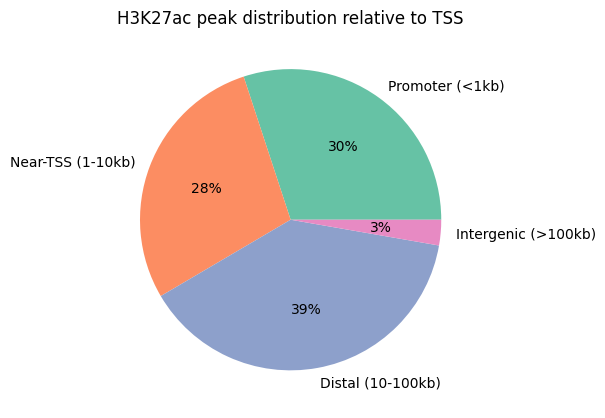

,count
region,
Promoter (<1kb),21199
Near-TSS (1-10kb),20043
Distal (10-100kb),27375
Intergenic (>100kb),1932


In [5]:
pk_bt  = pybedtools.BedTool.from_dataframe(peaks[['chrom','start','end','name']]).sort()
tss_bt = pybedtools.BedTool('tss.bed').sort()
closest = pk_bt.closest(tss_bt, d=True).to_dataframe(
    names=['chrom','start','end','peak','t_chrom','t_start','t_end','gene','score','strand','dist'])

def region(d):
    d = abs(d)
    if d <= 1000: return 'Promoter (<1kb)'
    if d <= 10000: return 'Near-TSS (1-10kb)'
    if d <= 100000: return 'Distal (10-100kb)'
    return 'Intergenic (>100kb)'
closest['region'] = closest['dist'].apply(region)
counts = closest['region'].value_counts()[['Promoter (<1kb)','Near-TSS (1-10kb)','Distal (10-100kb)','Intergenic (>100kb)']]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.0f%%', colors=sns.color_palette('Set2'))
plt.title('H3K27ac peak distribution relative to TSS'); plt.tight_layout()
plt.savefig('results/peak_genomic_distribution.png', dpi=120); plt.show()
counts

## 6. TSS enrichment heatmap (deepTools)

The signature ChIP-seq figure — signal piled up in a window around every gene's TSS.

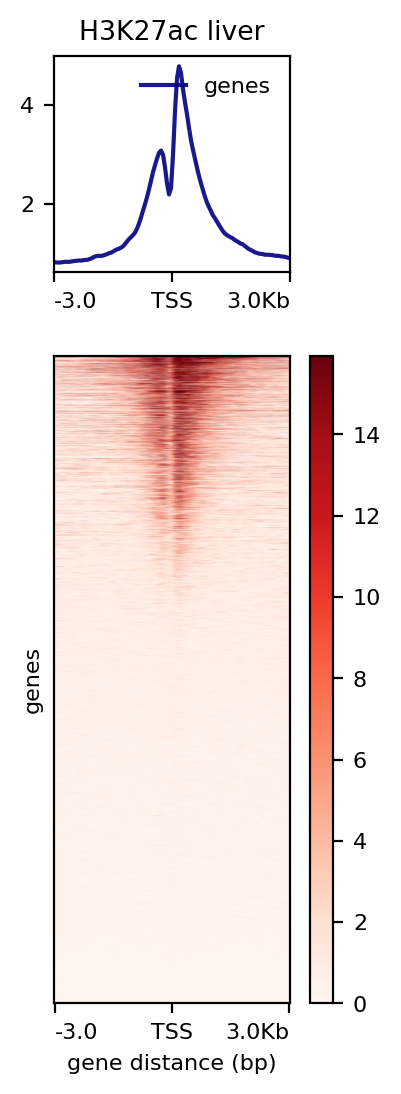

In [6]:
# use a subset of TSS for speed
tss.sample(min(8000, len(tss)), random_state=0).sort_values(['chrom','start']).to_csv(
    'tss_sub.bed', sep='\t', header=False, index=False)

!computeMatrix reference-point --referencePoint TSS -S signal.bw -R tss_sub.bed \
    -a 3000 -b 3000 --binSize 50 --missingDataAsZero -p 4 -o tss_matrix.gz 2>/dev/null
!plotHeatmap -m tss_matrix.gz -o results/tss_enrichment_heatmap.png \
    --colorMap Reds --heatmapHeight 12 --refPointLabel TSS \
    --regionsLabel "genes" --samplesLabel "H3K27ac liver" 2>/dev/null
!plotProfile -m tss_matrix.gz -o results/tss_enrichment_profile.png \
    --refPointLabel TSS --regionsLabel "genes" --samplesLabel "H3K27ac liver" 2>/dev/null

from IPython.display import Image, display
display(Image('results/tss_enrichment_heatmap.png'))

## 7. Genes with the strongest CTCF binding

In [7]:
# rank promoter-proximal peaks by ChIP signal, list the nearest genes
merged = closest.merge(peaks[['chrom','start','end','signalValue']], on=['chrom','start','end'], how='left')
promoter_hits = merged[merged['region']=='Promoter (<1kb)'].sort_values('signalValue', ascending=False)
top_genes = promoter_hits[['gene','signalValue','dist']].drop_duplicates('gene').head(20)
top_genes.to_csv('results/top_promoter_genes.csv', index=False)
top_genes

,gene,signalValue,dist
14484,DUSP16,105.82675,296
38604,HSPE1,97.39545,0
38605,HSPE1-MOB4,97.39545,0
57343,PNRC1,93.72432,0
57083,ENSG00000266680,91.36475,0
57084,ENSG00000285976,91.36475,0
56628,BICRAL,91.28282,0
52026,GOLPH3-DT,89.92921,0
52027,GOLPH3,89.92921,0
49488,N4BP2,89.05172,0


In [8]:
!zip -r results.zip results
from google.colab import files
files.download('results.zip')

  adding: results/ (stored 0%)
  adding: results/peak_genomic_distribution.png (deflated 10%)
  adding: results/tss_enrichment_heatmap.png (deflated 2%)
  adding: results/top_promoter_genes.csv (deflated 47%)
  adding: results/peak_stats.png (deflated 22%)
  adding: results/tss_enrichment_profile.png (deflated 10%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Summary

Mapped the active regulatory landscape of primary human liver from public ENCODE H3K27ac data:
called-peak statistics, the genomic distribution of marks relative to gene TSS, the TSS-enrichment
heatmap/profile, and the genes with the strongest promoter activity. H3K27ac's enrichment at active
promoters plus its spread over distal enhancers comes through clearly. Outputs are in `results/`.

To profile a different mark or factor (e.g. H3K4me3 for promoters, or CTCF for insulators) just change
`target.label` in section 2.